N= 2, τ=0.010, Eb=1.999400, Ergotropy=1.999400, erg/Eb=0.999999980007 Variance=5.9986652926e-04
N= 4, τ=0.010, Eb=3.998000, Ergotropy=3.998000, erg/Eb=0.999999960044 Variance=1.9998920578e-03
N= 6, τ=0.010, Eb=5.995801, Ergotropy=5.995800, erg/Eb=0.999999940139 Variance=4.2002983341e-03
N= 8, τ=0.010, Eb=7.992813, Ergotropy=7.992813, erg/Eb=0.999999921172 Variance=7.1895014703e-03
N=10, τ=0.010, Eb=9.989174, Ergotropy=9.989173, erg/Eb=0.999999904844 Variance=1.0831305368e-02


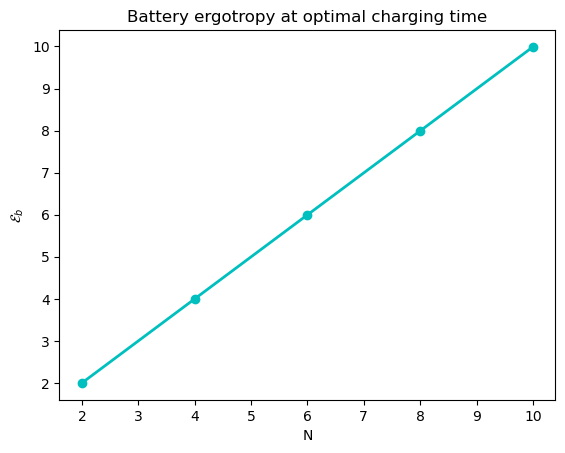

In [11]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 12, 2)
nmax = 20
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.1)

#############################
# Tavis–Cummings Hamiltonian
#############################

def tavis_cummings(N, nmax, ω, ω0, g):

    a  = qt.destroy(nmax)
    Ic = qt.qeye(nmax)

    sp, sm, sz = qt.sigmap(), qt.sigmam(), qt.sigmaz()

    def embed(op, i):
        ops = [qt.qeye(2)]*N
        ops[i] = op
        return qt.tensor(ops)

    Sp = sum(embed(sp, i) for i in range(N))
    Sm = Sp.dag()
    Sz = 0.5 * sum(embed(sz, i) for i in range(N))

    IB = qt.tensor([qt.qeye(2)]*N)
    HB = Sz + 0.5 * N * IB

    H = (ω * qt.tensor(a.dag()*a, IB) + ω0 * qt.tensor(Ic, HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

##################
# Initial state
##################

def initial_state(N, nmax, state):

    if state == "coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state == "fock":
        psiA = qt.basis(nmax, N)

    psiB = qt.tensor([qt.basis(2, 0) for _ in range(N)])
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ])
    
    rho_b = res.states[-1].proj().ptrace(list(range(1, N+1)))

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()
    
    r_vecs = np.sort(rho_b.eigenenergies())[::-1]
    
    # Passive Hamiltonian constructed in the passive state's eigenbasis
    
    e_vals, e_vecs = HB.eigenstates()
    
    H_passive = sum(e_vals[i] * r_vecs[i] * r_vecs[i].conj().T for i in range(len(e_vals)))

    # Ergotropy operator defined w.r.t. passive Hamiltonian
    
    E_op = HB - H_passive
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = qt.expect(E_op, rho_b)

    ΔE2 = qt.expect(E_op**2, rho_b) - E_erg**2
    
    ΔE = np.sqrt(qt.expect(E_op**2, rho_b) - E_erg**2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)

    print(f"N={N:2d}, τ={τ:.3f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f} Variance={ΔE2:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

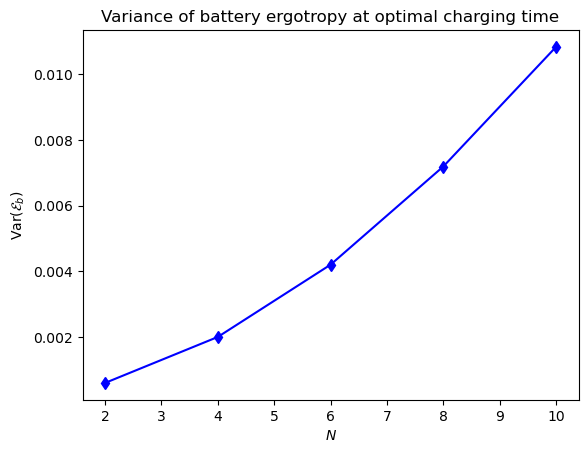

In [12]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

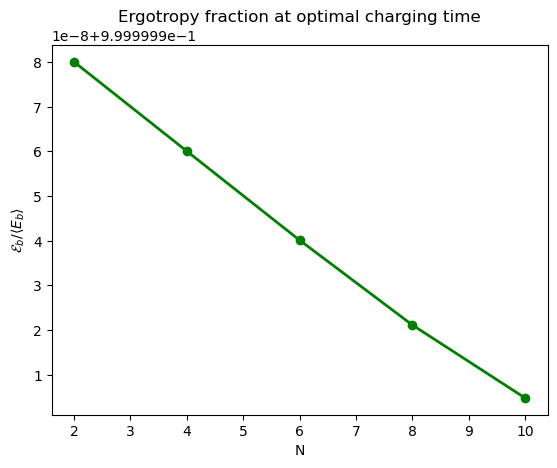

In [13]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

N= 2, τ=0.010, Relative Fluctuation =0.012249761254, Relative Fluctuation with Eb =0.012249761009
N= 4, τ=0.010, Relative Fluctuation =0.011185630915, Relative Fluctuation with Eb =0.011185630468
N= 6, τ=0.010, Relative Fluctuation =0.010809184005, Relative Fluctuation with Eb =0.010809183358
N= 8, τ=0.010, Relative Fluctuation =0.010608396660, Relative Fluctuation with Eb =0.010608395824
N=10, τ=0.010, Relative Fluctuation =0.010418635523, Relative Fluctuation with Eb =0.010418634531


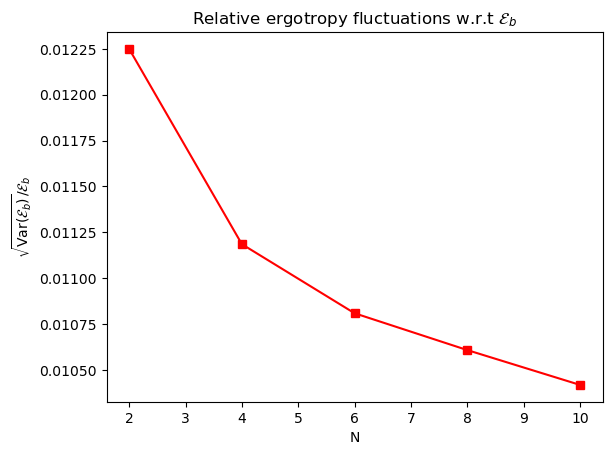

In [14]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.show()

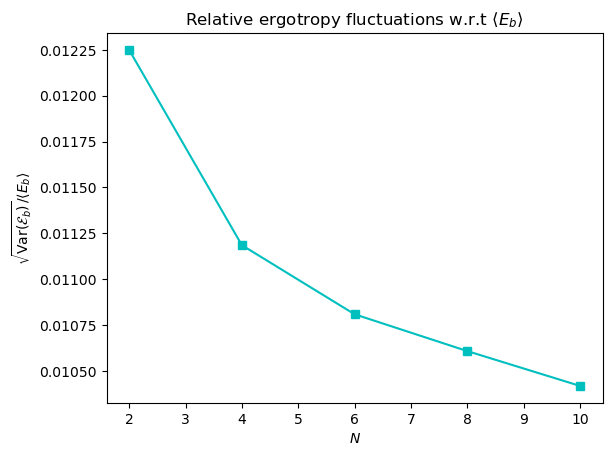

In [15]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()